In [1]:
import matplotlib.pyplot as plt
#plt.rcParams.update({
#    "font.family": "serif",
#    "font.serif": ["Palatino"],
#    "mathtext.fontset": "custom",
#    "mathtext.rm": "Palatino",
#})

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Palatino", "Palatino Linotype", "Book Antiqua", "DejaVu Serif"],
})

In [2]:
import os

os.listdir()

['per_layer_graphs',
 'per_layer_scores',
 'plots.ipynb',
 'last_layer_baseline_multiseed.csv',
 'model_accuracies_multiseed.csv',
 'model_rankings_multiseed.csv']

In [15]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

def plot_layer_scores_v0(folders):
    model_files = glob.glob(
        os.path.join(folders[0], "*_layer_scores_seed42.csv")
    )
    print(model_files)
    model_names = [
        os.path.basename(f).replace("_layer_scores_seed42.csv", "")
        for f in model_files
    ]

    n_models = len(model_names)
    print(model_names)
    fig, axes = plt.subplots(
        nrows= 1,
        ncols= n_models,
        figsize=(4 * n_models, 4),
        sharey=True
    )

    if n_models == 1:
        axes = [axes]

    for ax, model in zip(axes, model_names):
        for folder in folders:
            csv_path = os.path.join(
                folder,
                f"{model}_layer_scores_seed42.csv"
            )

            df = pd.read_csv(csv_path)

            ax.plot(
                df["layer_idx"],
                df["loes_score"],
                label=os.path.basename(folder),
                marker="o",
                markersize=4,
                linewidth=2
            )


        ax.set_title(model)
        ax.set_xlabel("Layer Index")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("LOES Score")
    axes[-1].legend()

    plt.tight_layout()
    plt.show()


In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

def plot_layer_scores_v1(folders):
    model_files = glob.glob(
        os.path.join(folders[0], "*_layer_scores_seed42.csv")
    )

    model_names = [
        os.path.basename(f).replace("_layer_scores_seed42.csv", "")
        for f in model_files
    ]

    n_models = len(model_names)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=n_models,
        figsize=(4 * n_models, 4),
        sharey=True
    )

    if n_models == 1:
        axes = [axes]

    for ax, model in zip(axes, model_names):
        for folder in folders:
            csv_path = os.path.join(
                folder,
                f"{model}_layer_scores_seed42.csv"
            )

            df = pd.read_csv(csv_path)

            ax.plot(
    df["layer_idx"],
    df["loes_score"],
    label=os.path.basename(folder),
    marker="o",
    markersize=4,
    linewidth=2.8
)


        ax.set_title(model, fontsize=12)
        ax.set_xlabel("Layer Index")
        ax.set_ylim(0.1, 1.0)
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.1)
        ax.minorticks_on()
        ax.tick_params(axis="both", labelsize=9)

    #fig.supylabel("LOES Score", fontsize=12)
    fig.supylabel(
    "LOES Score",
    fontsize=13,
    x=0.05
)




    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(labels),
        frameon=False,
        bbox_to_anchor=(0.5, 1.08)
    )

    #plt.tight_layout()
    plt.tight_layout(rect=[0.05, 0.0, 1.0, 1.0])
    plt.show()
    plt.savefig("per_layer_scores/layerwise_loes.pdf", bbox_inches="tight")


In [42]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_layer_scores(folders):
    # Find model names based on the first folder
    model_files = glob.glob(
        os.path.join(folders[0], "*_layer_scores_seed42.csv")
    )

    model_names = [
        os.path.basename(f).replace("_layer_scores_seed42.csv", "")
        for f in model_files
    ]
    model_names.remove('DINOv3-S16')    #* skip dinov3

    n_models = len(model_names)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=n_models,
        figsize=(4 * n_models, 4),
        sharey=False  # Changed to False for independent scaling
    )

    if n_models == 1:
        axes = [axes]

    dict1={'stanford_cars':'Stanford Cars', 'imagenet-1k': 'ImageNet-1k', 'stanford-dogs': 'Stanford Dogs', 'sun397': 'SUN397', 'cifar100': 'CIFAR-100','dtd': 'DTD'}
    
    for ax, model in zip(axes, model_names):  
        # Track min and max for this specific graph across all folders
        graph_min = float('inf')
        graph_max = float('-inf')

        for folder in folders:
            csv_path = os.path.join(
                folder,
                f"{model}_layer_scores_seed42.csv"
            )

            df = pd.read_csv(csv_path)
            
            # Update min/max tracking
            current_min = df["loes_score"].min()
            current_max = df["loes_score"].max()
            if current_min < graph_min: graph_min = current_min
            if current_max > graph_max: graph_max = current_max

            ax.plot(
                df["layer_idx"],
                df["loes_score"],
                label=dict1[os.path.basename(folder)],
                marker="o",
                markersize=4,
                linewidth=2.8
            )

        ax.set_title(model, fontsize=20)
        #!ax.set_xlabel("Layer Index",fontsize=20)
        
        # Set dynamic limits (min - 0.5 to max + 0.5)
        ax.set_ylim(graph_min - 0.05, graph_max + 0.05)

        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.1)
        ax.minorticks_on()
        
        # Hide Y axis values (labelleft=False), keep X axis values
        ax.tick_params(axis="both", labelsize=9)
        ax.tick_params(axis="y", labelleft=False) 

    fig.supylabel(
        "LOES Score",
        fontsize=20,
        x=0.05
    )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(labels),
        frameon=False,
        bbox_to_anchor=(0.5, 1.18),
        fontsize=20
    )

    plt.tight_layout(rect=[0.05, 0.0, 1.0, 1.0])
    plt.savefig("per_layer_scores/layerwise_loes.pdf", bbox_inches="tight")
    plt.show()
    # plt.savefig("per_layer_scores/layerwise_loes.pdf", bbox_inches="tight")

# Example usage (commented out):
# plot_layer_scores(["folder_path_1", "folder_path_2"])

In [35]:
os.getcwd()

'/home/arush/arnesh/image_classification/multi_model_analysis_multiseed_Final'

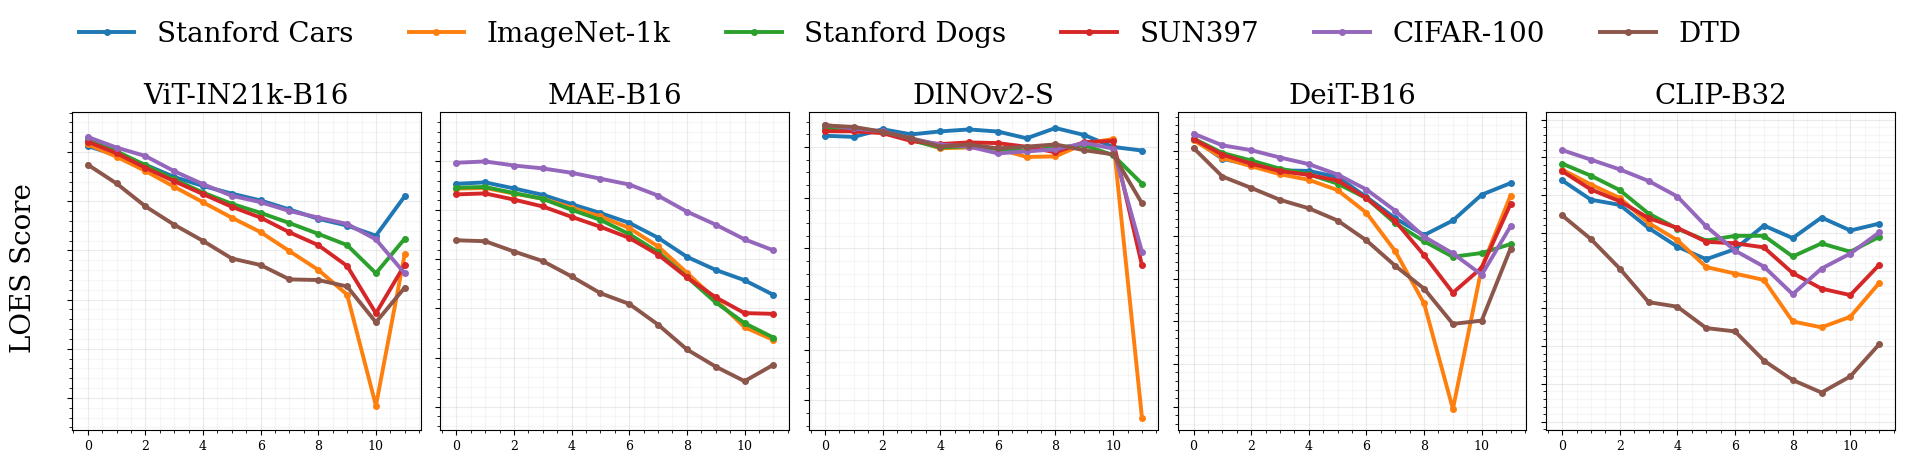

In [43]:
folders = [
    "/home/arush/arnesh/image_classification/multi_model_analysis_multiseed_Final/per_layer_scores/stanford_cars",
    #"/home/arush/arnesh/image_classification/multi_model_analysis_multiseed_Final/per_layer_scores/mini-imagenet",
    "/home/arush/arnesh/image_classification/multi_model_analysis_multiseed_Final/per_layer_scores/imagenet-1k",
    "/home/arush/arnesh/image_classification/multi_model_analysis_multiseed_Final/per_layer_scores/stanford-dogs",
    "/home/arush/arnesh/image_classification/multi_model_analysis_multiseed_Final/per_layer_scores/sun397",
    "/home/arush/arnesh/image_classification/multi_model_analysis_multiseed_Final/per_layer_scores/cifar100",
    "/home/arush/arnesh/image_classification/multi_model_analysis_multiseed_Final/per_layer_scores/dtd",
]

plot_layer_scores(folders)


<Figure size 640x480 with 0 Axes>